Install Required Tools

In [16]:
from google.colab import files
files.download('/content/Result of factor analysis.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
!pip install pandas scikit-learn openpyxl


Load Excel File

In [18]:
import pandas as pd

# Load the Excel file with correct name
df = pd.read_excel("/content/Result of factor analysis.xlsx")

# Preview the data
df.head()


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Factor1_score,Factor2_score,Factor3_score,Factor4_score,Factor5_score,Factor6_score,Factor7_score,Factor8_score,Factor9_score,Factor10_score
0,Name,UID,Age,Gender,Grade,Location,Do you face difficulty in understanding certai...,Which subject do you struggle with the most?,How often do you feel lost during classes?,What are the main reasons for missing classes?,...,0.443929,-0.198773,-1.643880,-0.263728,-0.806593,-1.704957,0.244162,0.439258,1.768638,0.140889
1,Rishi Rana,24BDA70035,20,1,8,10,Yes,COA,Sometimes,Health issue,...,-0.181427,-0.307468,0.323301,0.617870,-0.348333,-0.558240,0.188346,0.320301,-0.530893,0.438533
2,Manthan dhand,24BDA70012,19,1,7.5,11,Sometimes,Maths,Sometimes,Lack of interest,...,0.458392,-1.156504,1.579566,-0.994229,-0.863827,-0.597490,-0.415283,0.913228,-0.008607,0.214675
3,Manthan kumar,24BCY70356,19,1,6,10,Yes,COA,Sometimes,Lack of interest,...,0.251635,2.174534,-0.768676,-1.063205,1.012695,-0.235254,-1.126661,-0.499927,-0.808253,0.938678
4,Piyush,24BDA70075,18,1,7.78,11,Yes,COA,Sometimes,Lack of interest,...,-0.622766,-0.100104,0.255121,-0.275093,-0.332956,-0.203535,1.337950,-2.564748,0.629220,-0.230707


Create a Dictionary of New Names

In [19]:
factor_names = {
    "Factor1_score": "Learning Challenges",
    "Factor2_score": "Support & Resources",
    "Factor3_score": "Learning Preferences",
    "Factor4_score": "Feedback & Motivation",
    "Factor5_score": "Practice & Recommendations",
    "Factor6_score": "Device & App Usage",
    "Factor7_score": "Connectivity & Offline Access",
    "Factor8_score": "Adaptive Learning Experience",
    "Factor9_score": "Progress Tracking & Alerts",
    "Factor10_score": "Guidance & Motivation Tools"
    # Add Factor11 to Factor19 here if needed
}


Apply the Renaming

In [20]:
df.rename(columns=factor_names, inplace=True)


Clean the Data

In [22]:
# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows with missing values
df = df.dropna()


Choose What to Predict

In [24]:
X = df[[col for col in df.columns if col in factor_names.values() and col != "Learning Challenges"]]
y = df["Learning Challenges"]


Train the Linear Regression Model

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)


LinearRegression()

Calculate R² Score

In [26]:
r_squared = model.score(X, y)
print(f"R² Score: {r_squared:.4f}")


R² Score: 0.0063


Try Predicting a Different Factor

In [28]:
y = df["Support & Resources"]


Print All Column Names

In [29]:
print(df.columns.tolist())


['Learning Challenges', 'Support & Resources', 'Learning Preferences', 'Feedback & Motivation', 'Practice & Recommendations', 'Device & App Usage', 'Connectivity & Offline Access', 'Adaptive Learning Experience', 'Progress Tracking & Alerts', 'Guidance & Motivation Tools']


Select Input Features (X)

In [30]:
X = df[[col for col in df.columns if "Factor" in col and col != "Factor2_score"]]


Train and Evaluate the New Model

In [32]:
from sklearn.linear_model import LinearRegression

# Define target column
target_column = "Support & Resources"  # Replace with any renamed factor

# Define X and y
X = df[[col for col in df.columns if col in factor_names.values() and col != target_column]]
y = df[target_column]

# Drop missing values if any
X = X.dropna()
y = y.loc[X.index]  # Align y with cleaned X

# Train the model
model = LinearRegression()
model.fit(X, y)

# Evaluate the model
r_squared = model.score(X, y)
print(f"✅ R² Score for '{target_column}': {r_squared:.4f}")


✅ R² Score for 'Support & Resources': 0.0098


Loop Through All Factor Scores Automatically

In [33]:
from sklearn.linear_model import LinearRegression

for target in df.columns:
    if "Factor" in target:
        X = df[[col for col in df.columns if "Factor" in col and col != target]]
        y = df[target]
        model = LinearRegression()
        model.fit(X, y)
        r2 = model.score(X, y)
        print(f"R² Score for {target}: {r2:.4f}")


Visualize Actual vs Predicted (for any one target)

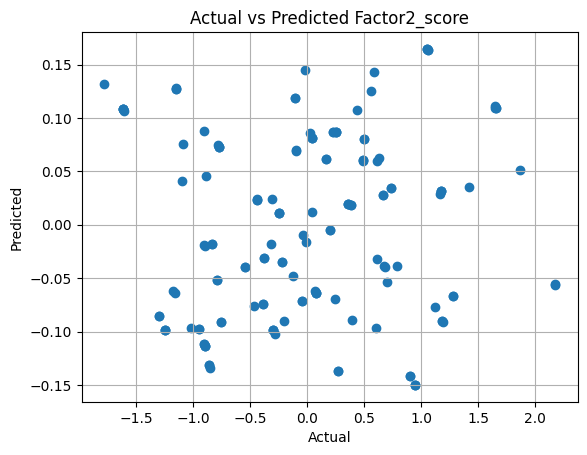

In [34]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Factor2_score")
plt.grid(True)
plt.show()


Loop Through All Factor Scores Automatically

In [35]:
from sklearn.linear_model import LinearRegression

for target in df.columns:
    if "Factor" in target:
        X = df[[col for col in df.columns if "Factor" in col and col != target]]
        y = df[target]
        model = LinearRegression()
        model.fit(X, y)
        r2 = model.score(X, y)
        print(f"R² Score for {target}: {r2:.4f}")


Visualize Each One

In [36]:
import matplotlib.pyplot as plt

for target in df.columns:
    if "Factor" in target:
        X = df[[col for col in df.columns if "Factor" in col and col != target]]
        y = df[target]
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        plt.figure()
        plt.scatter(y, y_pred)
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"Actual vs Predicted {target}")
        plt.grid(True)
        plt.show()


Install SHAP

In [37]:
!pip install shap


Import and Initialize

In [38]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X)


Visualize Feature Impact

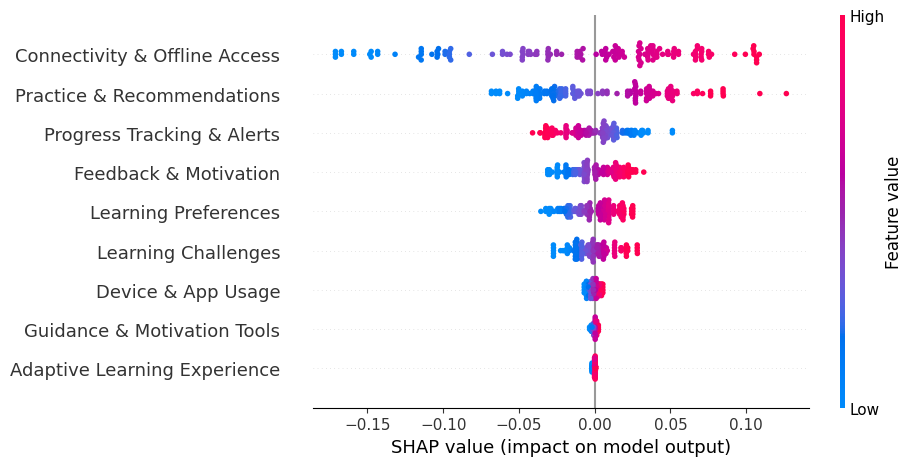

In [39]:
shap.plots.beeswarm(shap_values)


Explain a Single Prediction

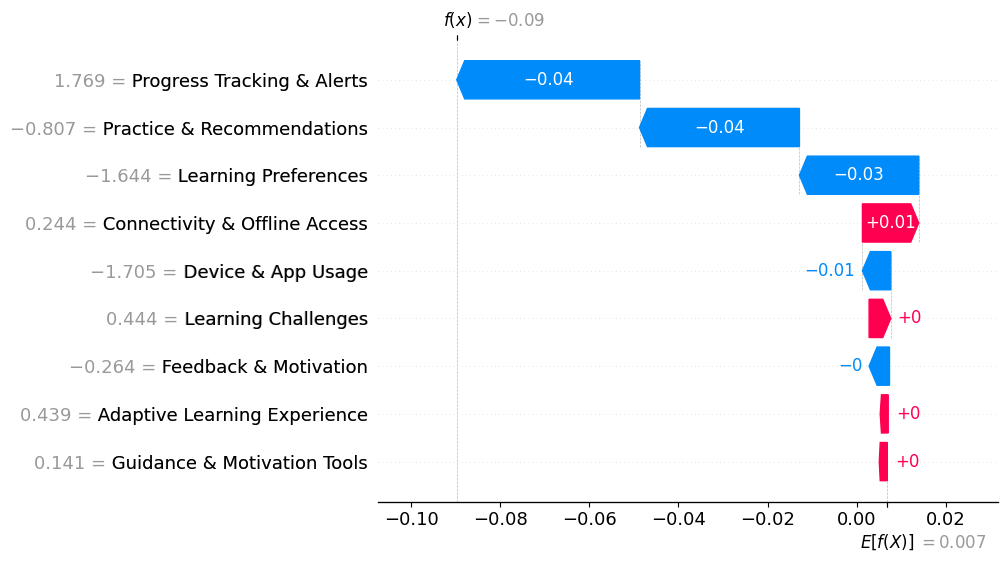

In [40]:
shap.plots.waterfall(shap_values[0])


Adaptive Learning Experience' as Target Variable


In [42]:
target_column = "Adaptive Learning Experience"

y = df[target_column]
X = df[[col for col in df.columns if col in factor_names.values() and col != target_column]]

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)
print(f"R² Score for '{target_column}': {r_squared:.4f}")


R² Score for 'Adaptive Learning Experience': 0.0027


Visualize Actual vs Predicted

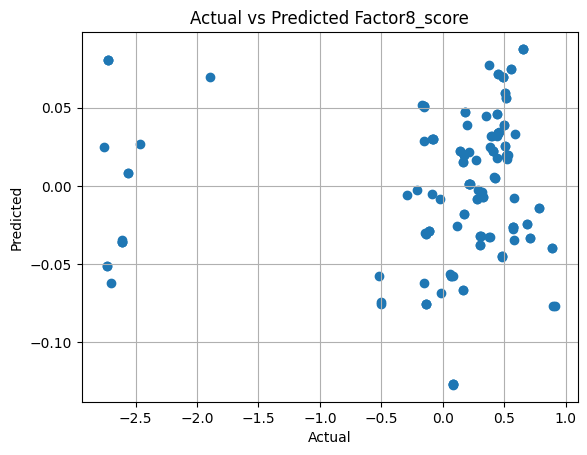

In [43]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Factor8_score")
plt.grid(True)
plt.show()


Use SHAP for Explainability

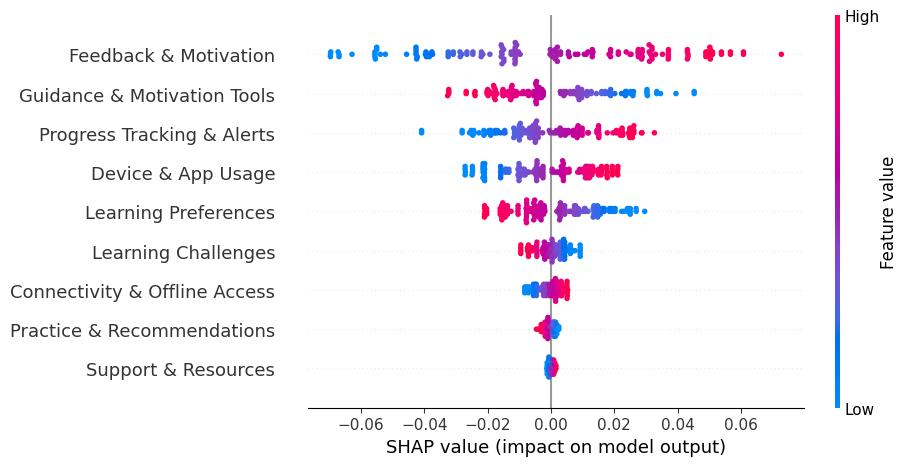

In [44]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

shap.plots.beeswarm(shap_values)


Calculate MSE in Current Setup

In [45]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse:.4f}")


Mean Squared Error: 0.8336


Want to Compare Models

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X, y)
lr_pred = lr_model.predict(X)
lr_mse = mean_squared_error(y, lr_pred)
print(f"Linear Regression MSE: {lr_mse:.4f}")

# Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(X, y)
rf_pred = rf_model.predict(X)
rf_mse = mean_squared_error(y, rf_pred)
print(f"Random Forest MSE: {rf_mse:.4f}")


Linear Regression MSE: 0.8336
Random Forest MSE: 0.0270


GOAL: Predict Factor8_score using other factor scores and explain the model using SHAP

Install Required Libraries

In [47]:
!pip install pandas scikit-learn openpyxl shap matplotlib


Load and Clean the Excel File

In [50]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("/content/Result of factor analysis.xlsx")  # ✅ updated file name

# Remove unnamed columns (often empty or auto-generated)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows with any missing values
df = df.dropna()

# Rename factor columns for clarity
factor_names = {
    "Factor1_score": "Learning Challenges",
    "Factor2_score": "Support & Resources",
    "Factor3_score": "Learning Preferences",
    "Factor4_score": "Feedback & Motivation",
    "Factor5_score": "Practice & Recommendations",
    "Factor6_score": "Device & App Usage",
    "Factor7_score": "Connectivity & Offline Access",
    "Factor8_score": "Adaptive Learning Experience",
    "Factor9_score": "Progress Tracking & Alerts",
    "Factor10_score": "Guidance & Motivation Tools"
    # Add Factor11 to Factor19 if needed
}

df.rename(columns=factor_names, inplace=True)

# ✅ Optional: Confirm renamed columns
print(df.columns.tolist())


['Learning Challenges', 'Support & Resources', 'Learning Preferences', 'Feedback & Motivation', 'Practice & Recommendations', 'Device & App Usage', 'Connectivity & Offline Access', 'Adaptive Learning Experience', 'Progress Tracking & Alerts', 'Guidance & Motivation Tools']


Select Target and Input Features

In [52]:
# Target variable
y = df["Adaptive Learning Experience"]

# Input features: all other renamed factor scores
X = df[[col for col in df.columns if col in factor_names.values() and col != "Adaptive Learning Experience"]]


Train the Linear Regression Model

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)


LinearRegression()

Visualize Actual vs Predicted

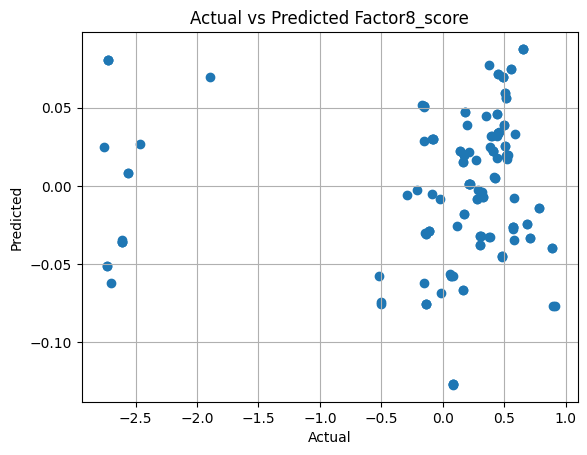

In [54]:
import matplotlib.pyplot as plt

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Factor8_score")
plt.grid(True)
plt.show()


Load SHAP and Explain the Model

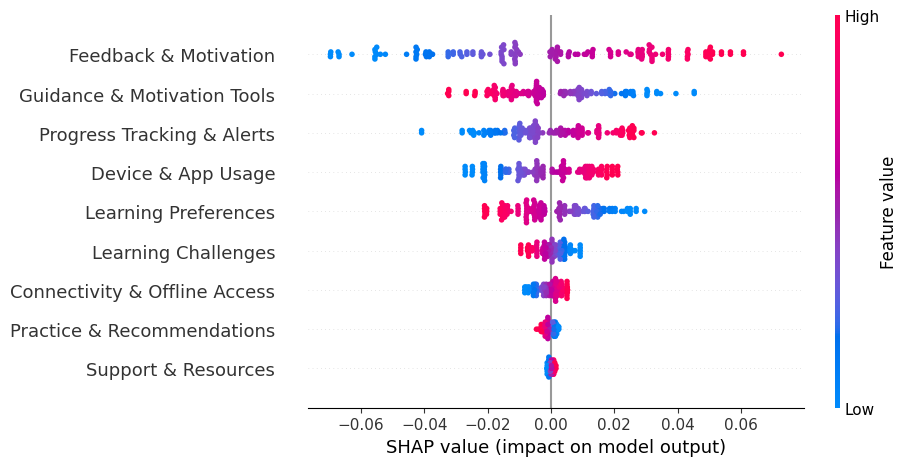

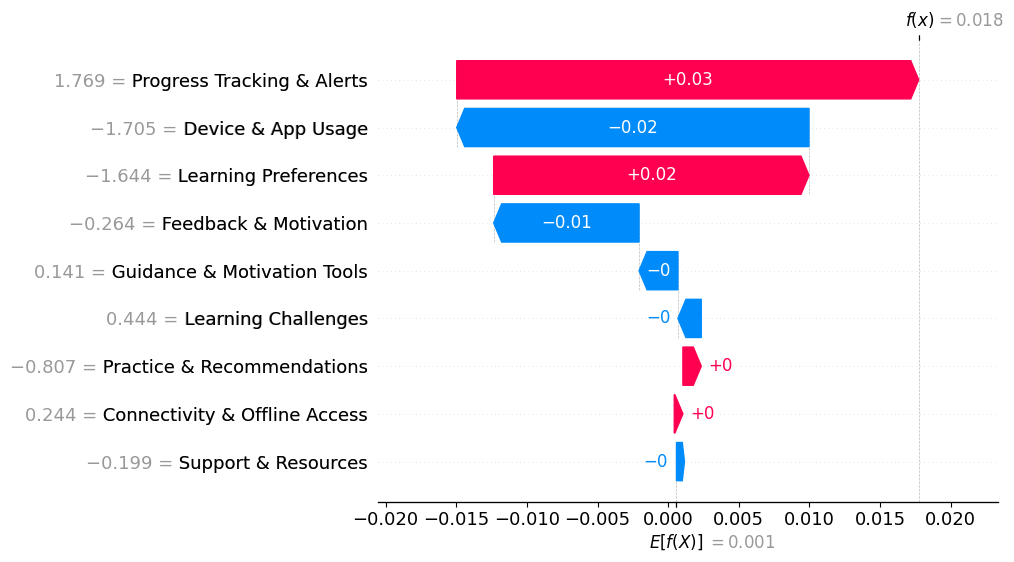

In [55]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# Beeswarm plot: feature impact across all predictions
shap.plots.beeswarm(shap_values)

# Optional: Waterfall plot for first prediction
shap.plots.waterfall(shap_values[0])


Install Required Libraries

In [56]:
!pip install pandas scikit-learn openpyxl shap matplotlib


Load and Clean the Excel File

In [58]:
import pandas as pd

# Load the Excel file (✅ updated file name)
df = pd.read_excel("/content/Result of factor analysis.xlsx")

# Remove unnamed columns (often empty or auto-generated)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows with any missing values
df = df.dropna()

# Rename factor columns for clarity
factor_names = {
    "Factor1_score": "Learning Challenges",
    "Factor2_score": "Support & Resources",
    "Factor3_score": "Learning Preferences",
    "Factor4_score": "Feedback & Motivation",
    "Factor5_score": "Practice & Recommendations",
    "Factor6_score": "Device & App Usage",
    "Factor7_score": "Connectivity & Offline Access",
    "Factor8_score": "Adaptive Learning Experience",
    "Factor9_score": "Progress Tracking & Alerts",
    "Factor10_score": "Guidance & Motivation Tools"
    # Add Factor11 to Factor19 if needed
}

df.rename(columns=factor_names, inplace=True)

# ✅ Optional: Confirm renamed columns
print(df.columns.tolist())


['Learning Challenges', 'Support & Resources', 'Learning Preferences', 'Feedback & Motivation', 'Practice & Recommendations', 'Device & App Usage', 'Connectivity & Offline Access', 'Adaptive Learning Experience', 'Progress Tracking & Alerts', 'Guidance & Motivation Tools']


Select Target and Input Features

In [59]:
# Target variable
y = df["Adaptive Learning Experience"]

# Input features: all other renamed factor scores
X = df[[col for col in df.columns if col in factor_names.values() and col != "Adaptive Learning Experience"]]


Train the Machine Learning Model

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)


LinearRegression()

Predict and Evaluate

In [61]:
y_pred = model.predict(X)

# R² Score
r_squared = model.score(X, y)
print(f"R² Score: {r_squared:.4f}")

# MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse:.4f}")


R² Score: 0.0027
Mean Squared Error: 0.8336


Visualize Actual vs Predicted

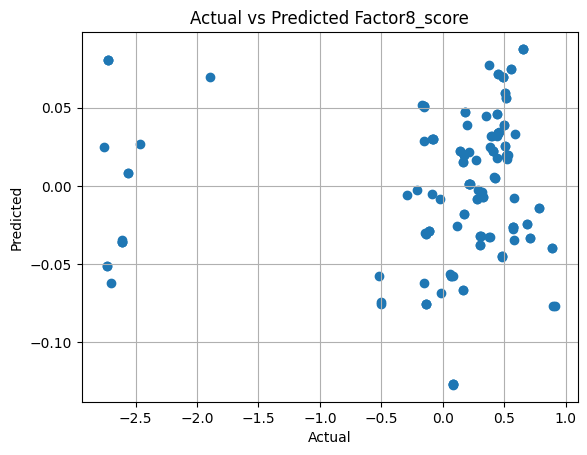

In [62]:
import matplotlib.pyplot as plt

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Factor8_score")
plt.grid(True)
plt.show()


SHAP Loading and Explainability

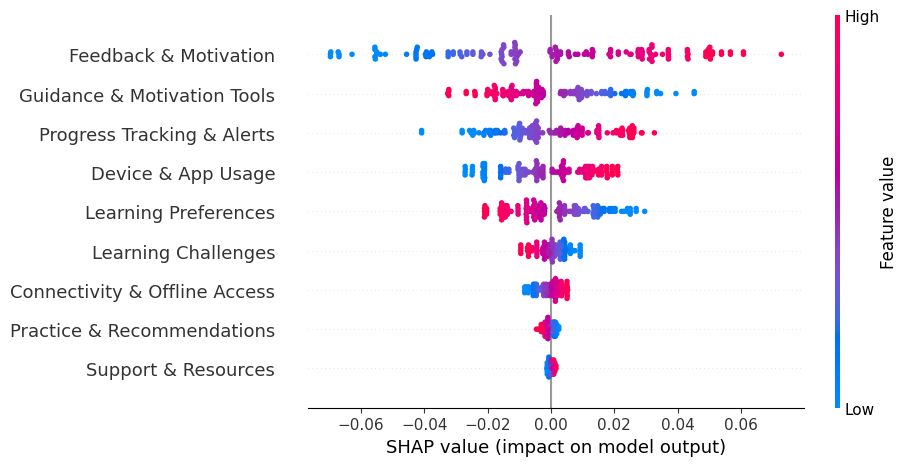

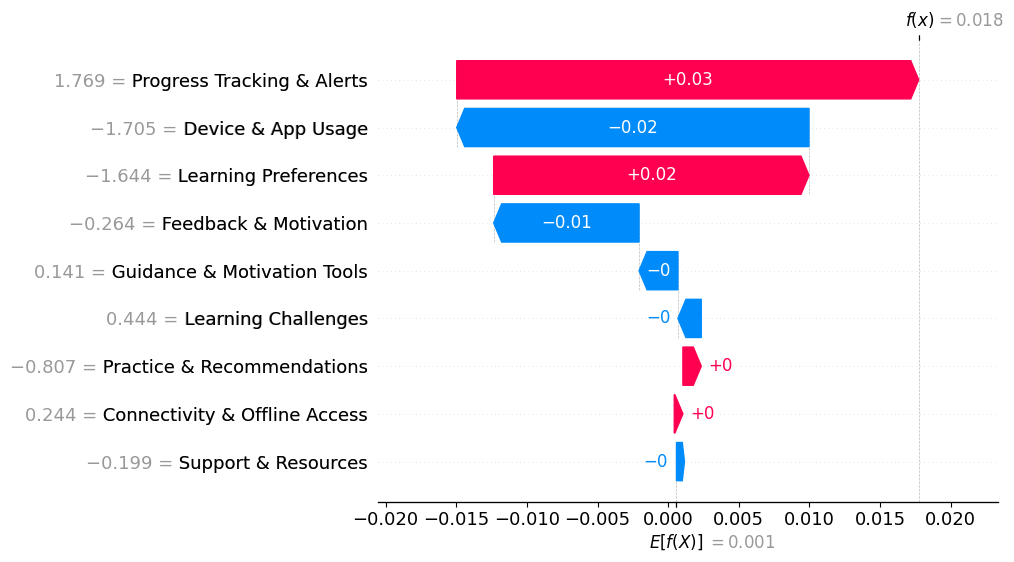

In [63]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# Beeswarm plot for overall feature impact
shap.plots.beeswarm(shap_values)

# Optional: Waterfall plot for one prediction
shap.plots.waterfall(shap_values[0])


Add a Markdown Header

In [64]:
## 🔄 Recommendation System Based on Factor Scores


Compute Cosine Similarity Between Students

In [65]:
from sklearn.metrics.pairwise import cosine_similarity

# Use all factor scores for similarity
similarity_matrix = cosine_similarity(df)
similarity_df = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)


Define a Recommendation Function

In [66]:
def recommend_similar(student_index, top_n=3):
    similar_students = similarity_df.loc[student_index].sort_values(ascending=False)[1:top_n+1]
    return similar_students


Try It Out

In [67]:
recommend_similar(0)


,0
6,0.911789
89,0.910197
114,0.910197


Check How Many Rows Are in Your DataFrame

In [68]:
print(len(df))


150


Generate Dummy Student IDs Automatically

In [69]:
df['student_id'] = ['S' + str(i+1) for i in range(len(df))]



Step-by-Step Fix for Cosine Similarity

Use Only Numeric Columns

In [70]:
# Select only numeric columns (factor scores)
numeric_df = df.select_dtypes(include='number')


Compute Cosine Similarity

In [71]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(numeric_df)
similarity_df = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)


Define Recommendation Function

In [72]:
def recommend_similar(student_index, top_n=3):
    similar_students = similarity_df.loc[student_index].sort_values(ascending=False)[1:top_n+1]
    return df.loc[similar_students.index, 'student_id'].tolist()


Try It Out

In [73]:
recommend_similar(0)


['S7', 'S90', 'S115']

Step-by-Step Code for Student Clustering

Use Only Numeric Factor Scores

In [74]:
# Select only the factor score columns (exclude student_id)
numeric_df = df.select_dtypes(include='number')


Apply KMeans Clustering

In [75]:
from sklearn.cluster import KMeans

# Create 3 student groups (you can change n_clusters to 4 or 5 if needed)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(numeric_df)


See How Many Students Are in Each Group

In [76]:
df['cluster'].value_counts()


,count
cluster,
1,62
2,62
0,26


Use Only Numeric Columns for Grouping

In [77]:
df.groupby("cluster")[df.select_dtypes(include='number').columns].mean()


,Learning Challenges,Support & Resources,Learning Preferences,Feedback & Motivation,Practice & Recommendations,Device & App Usage,Connectivity & Offline Access,Adaptive Learning Experience,Progress Tracking & Alerts,Guidance & Motivation Tools,cluster
cluster,,,,,,,,,,,
0,-0.021752,-0.545213,0.318571,0.069379,1.045325,0.883562,-0.289727,0.085592,-0.268072,0.068304,0.0
1,0.348469,-0.256328,-0.716937,0.089056,-0.207595,-0.375453,0.176749,-0.217947,0.059035,0.125397,1.0
2,-0.339348,0.484966,0.583343,-0.118150,-0.230767,0.004927,-0.055251,0.182054,0.053382,-0.154040,2.0


Export Clustered Data to Excel

In [78]:
df.to_excel("/content/student_clusters.xlsx", index=False)


Visualize Clusters with PCA (2D Plot)

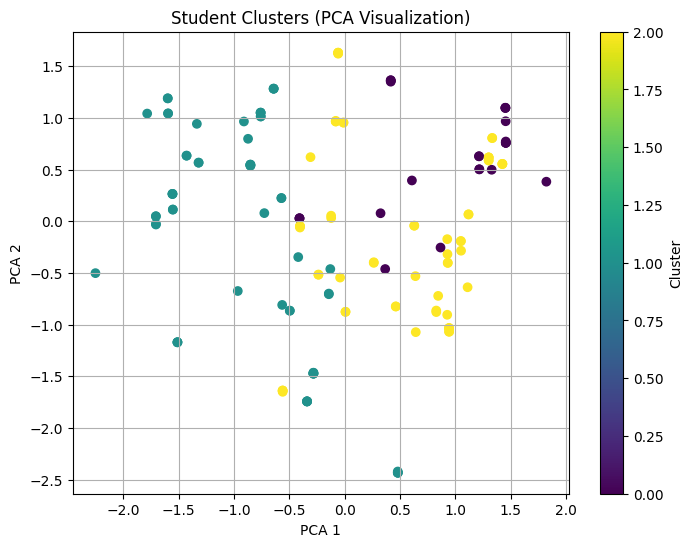

In [79]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
components = pca.fit_transform(numeric_df)

plt.figure(figsize=(8,6))
plt.scatter(components[:, 0], components[:, 1], c=df['cluster'], cmap='viridis')
plt.title("Student Clusters (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()


Train the Random Forest Classifier

In [80]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(numeric_df, df['cluster'])


RandomForestClassifier()

Use SHAP with

In [81]:
import shap

explainer = shap.Explainer(clf, numeric_df, model_output="probability")
shap_values = explainer(numeric_df)


Final Fix for SHAP Beeswarm with Clusters

Use

In [82]:
explainer = shap.Explainer(clf, numeric_df, model_output="probability")
shap_values = explainer(numeric_df)


Convert SHAP Values to a List of Arrays

In [83]:
# Get SHAP values for Cluster 0
cluster_0_shap = shap_values.values[:, :, 0]  # shape: (samples, features)

# Create a new Explanation object for Cluster 0
cluster_0_explainer = shap.Explanation(values=cluster_0_shap,
                                       base_values=shap_values.base_values[:, 0],
                                       data=numeric_df.values,
                                       feature_names=numeric_df.columns)


Plot Beeswarm for Cluster 0

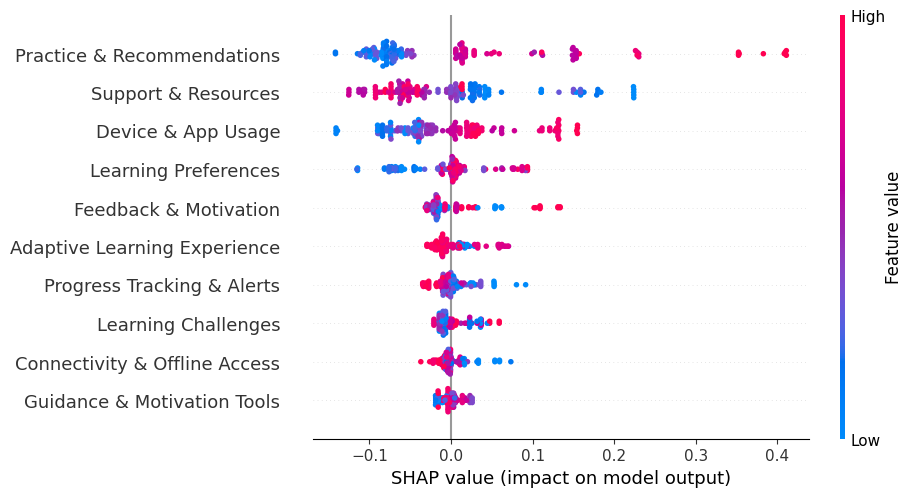

In [84]:
shap.plots.beeswarm(cluster_0_explainer)


Choose What You Want to Build

Export Everything to Excel

In [85]:
df.to_excel("/content/final_student_clusters.xlsx", index=False)


Build a Gradio App to Predict Cluster

Install Gradio

In [86]:
!pip install gradio


Define the Prediction Function

In [87]:
def predict_cluster(F1, F2, F3, F4, F5, F6, F7, F8, F9, F10):
    input_data = [[F1, F2, F3, F4, F5, F6, F7, F8, F9, F10]]
    cluster = kmeans.predict(input_data)[0]
    return f"Predicted Cluster: {cluster}"


Launch the Gradio Interface

In [88]:
import gradio as gr

inputs = [gr.Number(label=f"Factor{i+1}") for i in range(10)]
gr.Interface(fn=predict_cluster, inputs=inputs, outputs="text", title="Student Cluster Predictor").launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://25c064b9f369fb7a8b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Recommend Content Based on Cluster Profiles

Create a Content Mapping for Each Cluster

In [89]:
cluster_content = {
    0: ["Creative Writing", "Open-ended Projects"],
    1: ["Focused Practice", "Timed Quizzes"],
    2: ["Visual Learning", "Interactive Simulations"]
}


Add This to Your Gradio App

In [90]:
def recommend_cluster_content(F1, F2, F3, F4, F5, F6, F7, F8, F9, F10):
    input_data = [[F1, F2, F3, F4, F5, F6, F7, F8, F9, F10]]
    cluster = kmeans.predict(input_data)[0]

    # Recommend content
    content = cluster_content.get(cluster, ["General Support"])
    content_str = ", ".join(content)

    return f"Predicted Cluster: {cluster}", f"Recommended Content: {content_str}"


Update Gradio Interface

In [91]:
inputs = [gr.Number(label=f"Factor{i+1}") for i in range(10)]
gr.Interface(fn=recommend_cluster_content,
             inputs=inputs,
             outputs=["text", "text"],
             title="Student Cluster Recommender").launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d37f38ad9be68661b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Fix It and Relaunch the App

Scroll to the Gradio Cell

In [92]:
gr.Interface(fn=recommend_cluster_content,
             inputs=inputs,
             outputs=["text", "text"],
             title="Student Cluster Recommender").launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7b585e6667340117ea.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Run That Cell Again

In [93]:
gr.Interface(fn=recommend_cluster_content,
             inputs=inputs,
             outputs=["text", "text"],
             title="Student Cluster Recommender").launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bb435ec4dc07d8523d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Update Gradio Input Labels

In [96]:
gr.Number(label="Learning Challenges")
gr.Number(label="Support & Resources")


Finalize and Launch Your Gradio App

In [97]:
import gradio as gr

# Define the prediction + recommendation function
def recommend_cluster_content(F1, F2, F3, F4, F5, F6, F7, F8, F9, F10):
    input_data = [[F1, F2, F3, F4, F5, F6, F7, F8, F9, F10]]
    cluster = kmeans.predict(input_data)[0]
    content = cluster_content.get(cluster, ["General Support"])
    content_str = ", ".join(content)
    return f"Predicted Cluster: {cluster}", f"Recommended Content: {content_str}"

# Define readable input labels
inputs = [
    gr.Number(label="Learning Challenges"),
    gr.Number(label="Support & Resources"),
    gr.Number(label="Learning Preferences"),
    gr.Number(label="Feedback & Motivation"),
    gr.Number(label="Practice & Recommendations"),
    gr.Number(label="Device & App Usage"),
    gr.Number(label="Connectivity & Offline Access"),
    gr.Number(label="Adaptive Learning Experience"),
    gr.Number(label="Progress Tracking & Alerts"),
    gr.Number(label="Guidance & Motivation Tools")
]

# Launch the Gradio app
gr.Interface(
    fn=recommend_cluster_content,
    inputs=inputs,
    outputs=["text", "text"],
    title="Student Cluster Recommender"
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://70aebbeb236f50680f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
